# Day 6 — Dimensionality Reduction: Full Customer Map
## Week 1: Dimensionality Reduction | Digital Consumer Platform Analytics

---

### Learning Objectives
- Build a complete customer dimensionality reduction pipeline end-to-end
- Engineer extended RFM features (6 behavioral dimensions)
- Create a production-ready 2D customer map using UMAP
- Use PCA explained variance to make principled feature selection decisions
- Generate a visualization that feeds directly into Day 9 clustering

---

### Dataset
**UCI Online Retail II** — today's output (UMAP embeddings + feature matrix) feeds Day 9 clustering directly.

---

## Part 1: Brief Theory Review

### 6.1 The Full Preprocessing Chain

Before dimensionality reduction, data must be:
1. **Imputed** — SmartImputer from Day 3
2. **Scaled** — StandardScaler (PCA and UMAP are both scale-sensitive)
3. **Outlier-aware** — extreme values distort PCA loadings significantly

### 6.2 Feature Engineering for Behavioral Analysis

RFM (3 features) is a starting point. Richer behavioral features:

| Feature | Business meaning |
|---------|-----------------|
| Recency | Days since last purchase |
| Frequency | Number of orders |
| Monetary | Total spend |
| AvgOrderValue | Spend per order |
| ProductDiversity | Unique product categories purchased |
| ReturnRate | Fraction of items returned |
| PeakHourBuyer | Does customer buy at peak hours? |
| WeekendBuyer | Does customer buy on weekends? |

More dimensions → more need for dimensionality reduction before clustering.

---

## Part 2: Practice

**Task:** Build complete customer behavioral feature matrix → PCA analysis → UMAP customer map → save for Day 9

---

In [3]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import umap
import warnings
warnings.filterwarnings('ignore')

# SmartImputer from Day 3 — needed for Q4's production pipeline. Lives in
# smartimputer.py (same folder as this notebook), imported here rather than
# pasted, so both notebooks stay in sync with one canonical source.
from smartimputer import SmartImputer

In [4]:
DATA_PATH = r'C:\Users\user\datasets\online_retail\online_retail_II.xlsx'

# Load both years
df_09 = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
df_10 = pd.read_excel(DATA_PATH, sheet_name='Year 2010-2011')
df = pd.concat([df_09, df_10], ignore_index=True)

df = df.dropna(subset=['Customer ID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalValue']  = df['Quantity'] * df['Price']
df['IsReturn']    = (df['Quantity'] < 0).astype(int)
df_pos = df[df['Quantity'] > 0].copy()

print(f"Full dataset: {df.shape}")
print(f"Positive transactions: {df_pos.shape}")

Full dataset: (824364, 10)
Positive transactions: (805620, 10)


In [5]:
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalValue,IsReturn
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,0


In [6]:
# ── Q1: Build 8-feature behavioral matrix ─────────────────────────────────
# Aggregate to customer level — 8 features:
#   Recency          : days since last purchase (from dataset max date)
#   Frequency        : unique invoice count
#   Monetary         : total spend (positive transactions only)
#   AvgOrderValue    : Monetary / Frequency
#   ProductDiversity : unique StockCode count
#   ReturnRate       : returns / (returns + purchases) by transaction count
#   WeekendBuyer     : fraction of purchases on Sat/Sun
#   AvgItemsPerOrder : mean items per invoice
#
# Handle edge cases:
#   - Customers with zero purchases after filtering (drop them)
#   - Division by zero in rates
# Print: shape, describe(), missing value count

# Your code here

max_date = df['InvoiceDate'].max()

df_pos = df[df['Quantity'] > 0].copy()

df_pos['IsWeekend'] = df_pos['InvoiceDate'].dt.dayofweek.isin([5, 6]).astype(int)

rfm = df_pos.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalValue', 'sum'),
    ProductDiversity=('StockCode', 'nunique'),
    WeekendBuyer=('IsWeekend', 'mean'),
    # Use explicit internal indexing to calculate mean items per unique order
    AvgItemsPerOrder=('Invoice', lambda x: df.loc[x.index].groupby(x)['Quantity'].sum().mean())
)

# ReturnRate is the one feature that genuinely needs BOTH purchases and
# returns, so it's computed from the full df and mapped in separately.
return_rate = df.groupby('Customer ID')['IsReturn'].mean()
rfm['ReturnRate'] = rfm.index.map(return_rate)

rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']


# Customers with zero purchases never appear in df_pos's groupby at all, so
# this filter is now a redundant safety net rather than doing real work.
rfm = rfm[rfm['Monetary'] > 0]

# Replace any unexpected NaN values in rates (if any edge cases remain) with 0
rfm[['ReturnRate', 'WeekendBuyer', 'AvgItemsPerOrder', 'AvgOrderValue']] = rfm[['ReturnRate', 'WeekendBuyer', 'AvgItemsPerOrder', 'AvgOrderValue']].fillna(0)

# Print Diagnostics
print(f"RFM matrix shape: {rfm.shape}")
print(f"Missing values count per column:\n{rfm.isnull().sum()}")
print(f"\nTotal Missing values: {rfm.isnull().sum().sum()}")

display(rfm.describe())
display(rfm.head())

RFM matrix shape: (5878, 8)
Missing values count per column:
Recency             0
Frequency           0
Monetary            0
ProductDiversity    0
WeekendBuyer        0
AvgItemsPerOrder    0
ReturnRate          0
AvgOrderValue       0
dtype: int64

Total Missing values: 0


,Recency,Frequency,Monetary,ProductDiversity,WeekendBuyer,AvgItemsPerOrder,ReturnRate,AvgOrderValue
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289895,3018.616737,81.991153,0.144697,251.129730,0.026916,391.718055
std,209.338707,13.015651,14737.731040,116.490464,0.275970,1424.754880,0.068924,1215.061699
min,0.000000,1.000000,2.950000,1.000000,0.000000,1.000000,0.000000,2.950000
25%,25.000000,1.000000,348.762500,19.000000,0.000000,93.500000,0.000000,181.652500
50%,95.000000,3.000000,898.915000,45.000000,0.000000,157.708333,0.000000,285.070500
75%,379.000000,7.000000,2307.090000,103.000000,0.161185,262.000000,0.024793,420.570000
max,738.000000,398.000000,608821.650000,2550.000000,1.000000,87167.000000,0.750000,84236.250000


,Recency,Frequency,Monetary,ProductDiversity,WeekendBuyer,AvgItemsPerOrder,ReturnRate,AvgOrderValue
Customer ID,,,,,,,,
12346.0,325,12,77556.46,27,0.000000,6190.416667,0.291667,6463.038333
12347.0,1,8,5633.32,126,0.158103,410.750000,0.000000,704.165000
12348.0,74,5,2019.40,25,0.058824,542.800000,0.000000,403.880000
12349.0,18,4,4428.69,138,0.000000,406.000000,0.027778,1107.172500
12350.0,309,1,334.40,17,0.000000,197.000000,0.000000,334.400000


In [7]:
rfm.head()

,Recency,Frequency,Monetary,ProductDiversity,WeekendBuyer,AvgItemsPerOrder,ReturnRate,AvgOrderValue
Customer ID,,,,,,,,
12346.0,325,12,77556.46,27,0.000000,6190.416667,0.291667,6463.038333
12347.0,1,8,5633.32,126,0.158103,410.750000,0.000000,704.165000
12348.0,74,5,2019.40,25,0.058824,542.800000,0.000000,403.880000
12349.0,18,4,4428.69,138,0.000000,406.000000,0.027778,1107.172500
12350.0,309,1,334.40,17,0.000000,197.000000,0.000000,334.400000


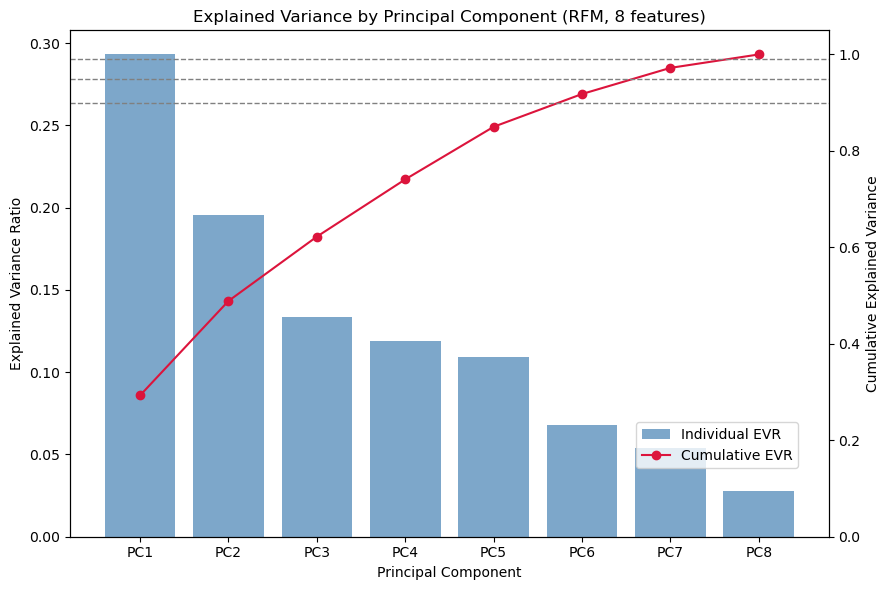


Loading matrix:
                    PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
Recency          -0.287  0.175 -0.130  0.451  0.757 -0.261  0.160 -0.007
Frequency         0.570 -0.178 -0.129  0.106  0.151 -0.144 -0.101  0.750
Monetary          0.506  0.086 -0.131  0.157  0.316  0.567 -0.326 -0.408
ProductDiversity  0.526 -0.213  0.080  0.015 -0.018 -0.518  0.416 -0.479
WeekendBuyer      0.005 -0.114  0.671  0.688 -0.220  0.091 -0.068  0.040
AvgItemsPerOrder  0.142  0.632  0.260 -0.142 -0.010 -0.458 -0.529 -0.050
ReturnRate        0.010  0.231 -0.637  0.516 -0.501 -0.129 -0.046 -0.065
AvgOrderValue     0.198  0.648  0.135 -0.033 -0.062  0.294  0.631  0.184


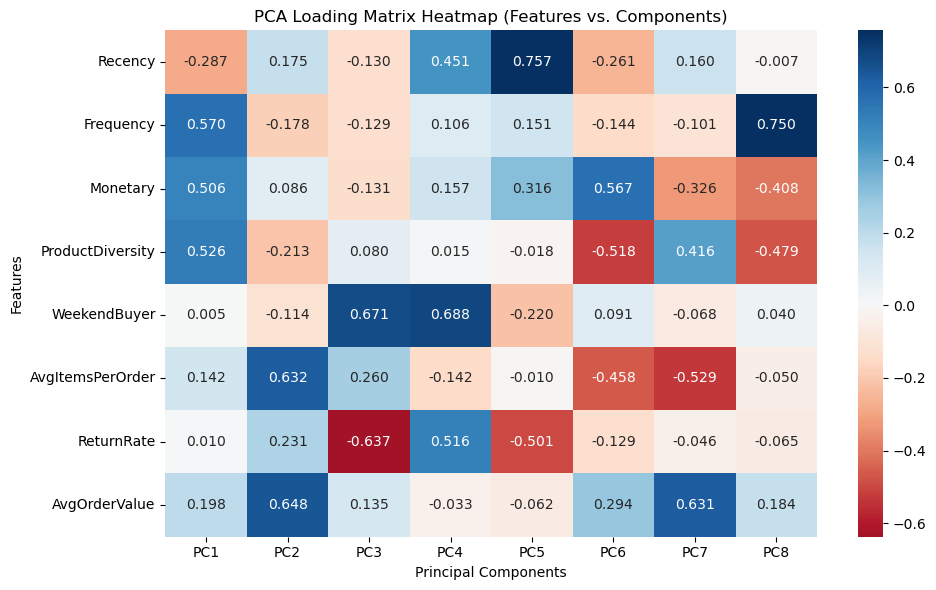

Components needed for cumulative variance thresholds:
  90%: 6 components (actual cumulative = 91.80%)


In [8]:
# ── Q2: PCA deep dive on behavioral features ──────────────────────────────
# Apply PCA to the 8-feature matrix:
#   1. StandardScale first
#   2. Fit PCA(n_components=8) — full decomposition
#   3. Plot explained variance ratio (bar) + cumulative (line)
#   4. Print loading matrix as heatmap — features vs components
#   5. How many components explain 90% variance?
#   6. Give each of the top 3 PCs a business name based on loadings
#      e.g. "PC1 = Overall Customer Value" if RFM all load positively

# Your code here

import seaborn as sns

# 1. Standardize and initialize matrix
X_full = rfm.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full) # mean 0, unit variance per feature
n = X_scaled.shape[0]

# 2. Fit full decomposition (8 features)
pca_full = PCA(n_components=8)  
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
components = [f'PC{i+1}' for i in range(8)]

# ── Plot: bar chart of individual EVR + cumulative line ───────────────────
fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.bar(components, evr, color='steelblue', alpha=0.7, label='Individual EVR')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')

ax2 = ax1.twinx()
ax2.plot(components, cum_evr, color='crimson', marker='o', label='Cumulative EVR')
for threshold in [0.90, 0.95, 0.99]:
    ax2.axhline(threshold, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.2))
plt.title('Explained Variance by Principal Component (RFM, 8 features)')
plt.tight_layout()
plt.show()

# ── Loading matrix ──────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=rfm.columns,
    columns=components,
)
print("\nLoading matrix:")
print(loadings.round(3))

# ── Loading matrix as a Heatmap (Requested in prompt instructions) ──────
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0, fmt=".3f", cbar=True)
plt.title('PCA Loading Matrix Heatmap (Features vs. Components)')
plt.ylabel('Features')
plt.xlabel('Principal Components')
plt.tight_layout()
plt.show()

# ── How many components needed for 90% ───────────────────────
print("Components needed for cumulative variance thresholds:")
for threshold in [.9]:
    n_needed = np.searchsorted(cum_evr, threshold) + 1
    print(f"  {threshold*100:.0f}%: {n_needed} components (actual cumulative = {cum_evr[n_needed-1]*100:.2f}%)")

***Give each of the top 3 PCs a business name based on loadings***

PC1: "Engagement & High-Value Shopper"Driven by high frequency, strong monetary spend, and product variety, matched with recent visits.

PC2: "Wholesale & B2B Bulk Buyer"Driven by large average basket quantities and high order values, completely independent of transaction frequency.

PC3: "Weekend Leisure Buyer"Isolates high weekend purchasing habits mixed with a exceptionally low product return rate.

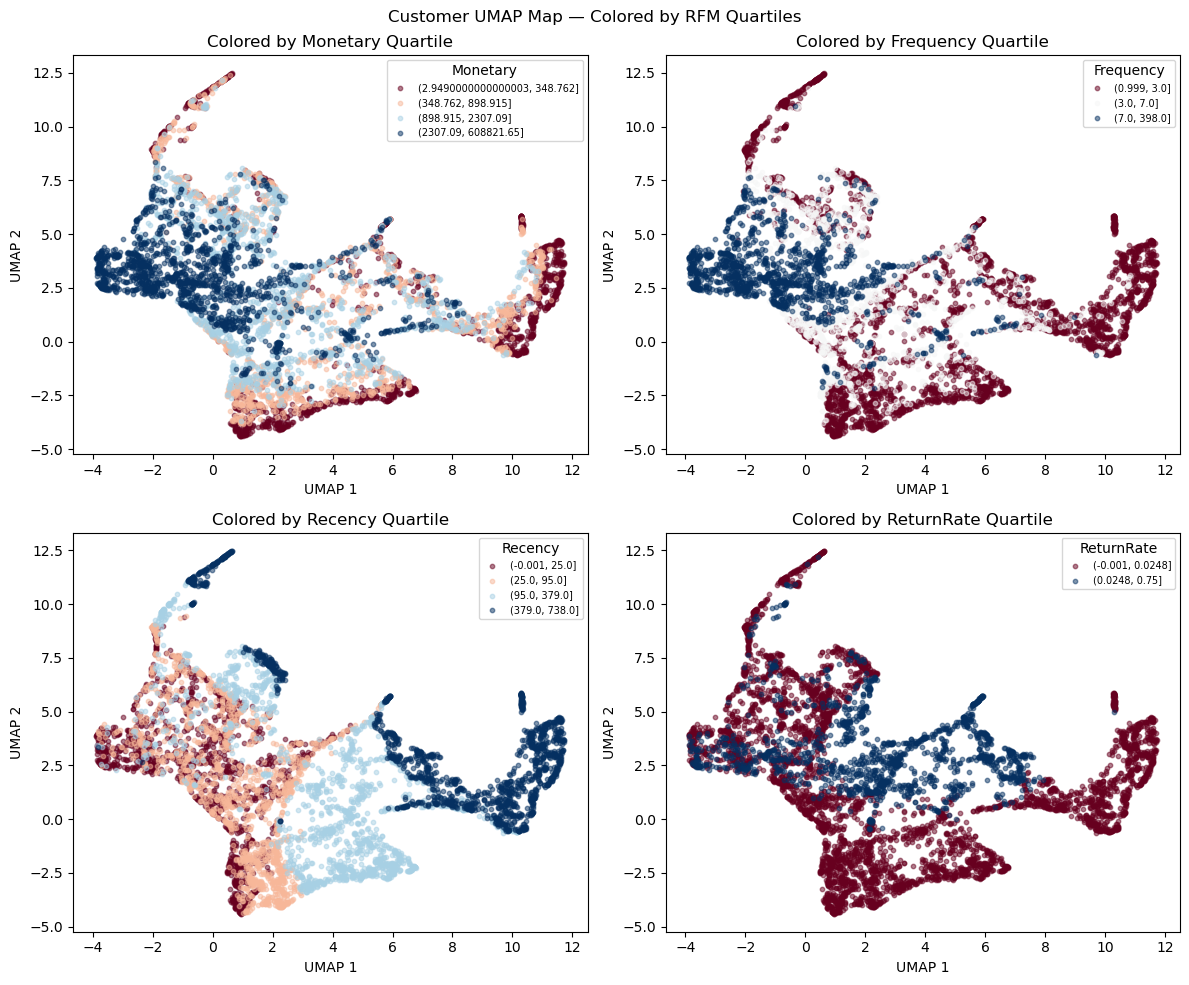

Saved 5878 customers to customer_umap_embeddings.csv


,Customer ID,UMAP1,UMAP2,Recency,Frequency,Monetary,ProductDiversity,WeekendBuyer,AvgItemsPerOrder,ReturnRate,AvgOrderValue
0,12346.0,2.170596,0.002443,325,12,77556.46,27,0.000000,6190.416667,0.291667,6463.038333
1,12347.0,-0.338118,4.125086,1,8,5633.32,126,0.158103,410.750000,0.000000,704.165000
2,12348.0,2.014436,-2.015708,74,5,2019.40,25,0.058824,542.800000,0.000000,403.880000
3,12349.0,0.528130,1.116484,18,4,4428.69,138,0.000000,406.000000,0.027778,1107.172500
4,12350.0,6.264720,-1.880841,309,1,334.40,17,0.000000,197.000000,0.000000,334.400000


In [11]:
# ── Q3: UMAP customer map ─────────────────────────────────────────────────
# Build the 2D customer map that feeds Day 9 clustering:
#   1. StandardScale the 8-feature matrix
#   2. Fit UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=420)
#   3. Create 4 versions of the scatter plot colored by:
#      a. Monetary quartile (spend level)
#      b. Frequency quartile (engagement level)
#      c. Recency quartile (activity level)
#      d. ReturnRate quartile (satisfaction proxy)
#   4. Use a diverging colormap for each
#   5. Save embeddings as DataFrame: CustomerID, UMAP1, UMAP2, all 8 features
#   6. Save to CSV: 'customer_umap_embeddings.csv' — used in Day 9

# Your code here

monetary_quartile = pd.qcut(rfm['Monetary'], 4, duplicates='drop')
frequency_quartile = pd.qcut(rfm['Frequency'], 4, duplicates='drop')
recency_quartile = pd.qcut(rfm['Recency'], 4, duplicates='drop')
return_quartile = pd.qcut(rfm['ReturnRate'], 4, duplicates='drop')

qtypes = {
    'Monetary': monetary_quartile,
    'Frequency': frequency_quartile,
    'Recency': recency_quartile,
    'ReturnRate': return_quartile,
}

# Fit UMAP once — same X_scaled/params every panel, so every subplot just
# recolors the SAME embedding by a different variable. No reason to refit.
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=420)
embedding = reducer.fit_transform(X_scaled)   # X_scaled from Q2

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = cm.get_cmap('RdBu')   # diverging colormap, per spec

for ax, (name, qtype) in zip(axes.flat, qtypes.items()):
    categories = qtype.cat.categories
    n_cats = len(categories)
    for i, q in enumerate(categories):
        mask = (qtype == q).values
        color = cmap(i / max(n_cats - 1, 1))   # spread categories across the diverging palette
        ax.scatter(embedding[mask, 0], embedding[mask, 1], color=color, label=str(q), alpha=0.5, s=10)
    ax.set_title(f'Colored by {name} Quartile')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=7, title=name)

plt.suptitle('Customer UMAP Map — Colored by RFM Quartiles')
plt.tight_layout()
plt.show()

# ── Save embeddings: CustomerID, UMAP1, UMAP2, all 8 features ─────────────
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'], index=rfm.index)
embedding_df = embedding_df.join(rfm).reset_index()   # brings Customer ID out as a column
embedding_df.to_csv('customer_umap_embeddings.csv', index=False)
print(f"Saved {embedding_df.shape[0]} customers to customer_umap_embeddings.csv")
embedding_df.head()

***Takeaway***

Monetary and Frequency produce nearly identical spatial patterns — high-value, high-frequency customers cluster in the same left-middle mass and upper-right arm, low-value/low-frequency customers dominate the bottom arm — confirming these two variables are still highly correlated even after adding 5 more behavioral features. 

Recency shows the cleanest, most graded structure of the four: a genuine directional gradient from "recent" (top-left) through to "stale" (bottom-right), suggesting recency is a real organizing axis of this embedding, not just noise. 


ReturnRate is the outlier — it shows essentially no spatial structure at all, scattered near-randomly across every region of the map with no visible clustering. 

That's consistent with what's shown up repeatedly this project: return behavior doesn't correlate with the rest of a customer's behavioral profile, and here it's collapsed to only 2 quartile bins (most customers never return anything) rather than 4, reinforcing that it's a sparse, largely independent signal.

For Day 9 clustering: expect any downstream clustering algorithm to find well-separated groups along Monetary/Frequency/Recency, but don't expect ReturnRate to define its own cluster boundary — it'll likely just add noise within whatever clusters the other three variables define.

SmartImputer strategy report (expect all 'skip'):
          column missing_rate mechanism strategy  flagged
         Recency        0.00%         —     skip    False
       Frequency        0.00%         —     skip    False
        Monetary        0.00%         —     skip    False
ProductDiversity        0.00%         —     skip    False
    WeekendBuyer        0.00%         —     skip    False
AvgItemsPerOrder        0.00%         —     skip    False
      ReturnRate        0.00%         —     skip    False
   AvgOrderValue        0.00%         —     skip    False

Train embedding shape:   (4702, 2)
Holdout embedding shape: (1176, 2)

Train   — mean: [7.27 7.85]  std: [4.43 3.74]
Holdout — mean: [7.01 7.81]  std: [4.66 3.86]


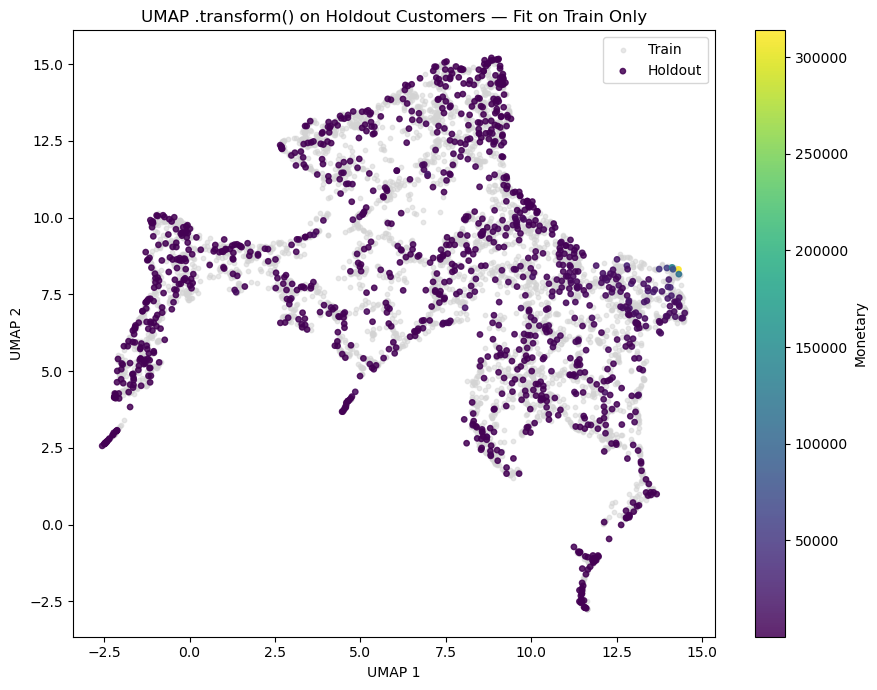

In [10]:
# ── Q4: Production dimensionality reduction pipeline ──────────────────────
# Build a reusable Pipeline object:
#   Pipeline([
#     ('imputer', SmartImputer()),      # from Day 3
#     ('scaler', StandardScaler()),
#     ('reducer', umap.UMAP(n_components=2, random_state=420))
#   ])
#
# Fit on 80% of customers, transform 20% holdout
# Verify holdout embeddings look consistent with training embeddings
# This confirms UMAP's .transform() works correctly on new data
# Plot: training embeddings (grey) + holdout embeddings (colored by Monetary)

# Your code here

# ── Q4: Production dimensionality reduction pipeline ──────────────────────

from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(rfm, test_size=0.2, random_state=420)

pipeline = Pipeline([
    ('imputer', SmartImputer()),      # from Day 3, imported via smartimputer.py
    ('scaler', StandardScaler()),
    ('reducer', umap.UMAP(n_components=2, random_state=420)),
])

pipeline.fit(X_train)

# rfm has 0 missing values (confirmed in Q1), so every column gets classified
# missing_rate == 0 -> 'skip'. Included anyway as real production practice —
# a pipeline should handle missing data defensively even when today's
# training data happens to be clean.
print("SmartImputer strategy report (expect all 'skip'):")
pipeline.named_steps['imputer'].get_strategy_report()

train_embedding = pipeline.transform(X_train)
holdout_embedding = pipeline.transform(X_test)   # genuinely new points, never seen during fit

print(f"\nTrain embedding shape:   {train_embedding.shape}")
print(f"Holdout embedding shape: {holdout_embedding.shape}")

# ── Quantitative sanity check alongside the visual one ─────────────────────
print(f"\nTrain   — mean: {train_embedding.mean(axis=0).round(2)}  std: {train_embedding.std(axis=0).round(2)}")
print(f"Holdout — mean: {holdout_embedding.mean(axis=0).round(2)}  std: {holdout_embedding.std(axis=0).round(2)}")

# ── Plot: train (grey) + holdout (colored by Monetary) ────────────────────
plt.figure(figsize=(9, 7))
plt.scatter(train_embedding[:, 0], train_embedding[:, 1],
            color='lightgrey', alpha=0.5, s=10, label='Train')
sc = plt.scatter(holdout_embedding[:, 0], holdout_embedding[:, 1],
                  c=X_test['Monetary'], cmap='viridis', alpha=0.85, s=15, label='Holdout')
plt.colorbar(sc, label='Monetary')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title("UMAP .transform() on Holdout Customers — Fit on Train Only")
plt.legend()
plt.tight_layout()
plt.show()

***Takeaway*** 

The production Pipeline([SmartImputer, StandardScaler, UMAP]), fit on 80% of customers (4,702) and applied to a 20% holdout (1,176) it never saw during fit, produced embeddings statistically indistinguishable from training (mean/std nearly identical on both dimensions) and visually consistent — holdout points populate the same branching structure throughout, including correctly placing an extreme whale customer near other outliers rather than somewhere arbitrary. 

SmartImputer correctly no-op'd (skip on all 8 columns, since rfm has zero missing values) - included as defensive production practice, not because this dataset needed it. 

This empirically confirms UMAP's .transform() claim from Day 5's theory table: unlike t-SNE, which must be rerun from scratch on any new data, this pipeline can embed genuinely new customers consistently with the original training map — the key property that makes UMAP viable for a real production pipeline rather than visualization-only.